In [18]:
import pydicom
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from skimage import measure, morphology
import scipy.ndimage as ndimage

In [19]:
#Loading data
DICOM_FOLDER = "C:/Users/keert/Downloads/lung-ct-segmentation/data/patient_001/03-14-2007-482-CT NON-INFUSED CHEST-12952/5.000000-HIGH RES-39835"

slices = []
for f in sorted(Path(DICOM_FOLDER).glob("*.dcm")):
    ds = pydicom.dcmread(str(f))
    slices.append(ds)

slices.sort(key=lambda x: float(x.ImagePositionPatient[2]))

print(f"Loaded {len(slices)} slices")
print(f"Image size: {slices[0].pixel_array.shape}")
print(f"Slice thickness: {slices[0].SliceThickness} mm")

Loaded 324 slices
Image size: (512, 512)
Slice thickness: 1.00 mm


HU range: -1024 to 2976
Volume shape: (324, 512, 512)  →  (slices, height, width)


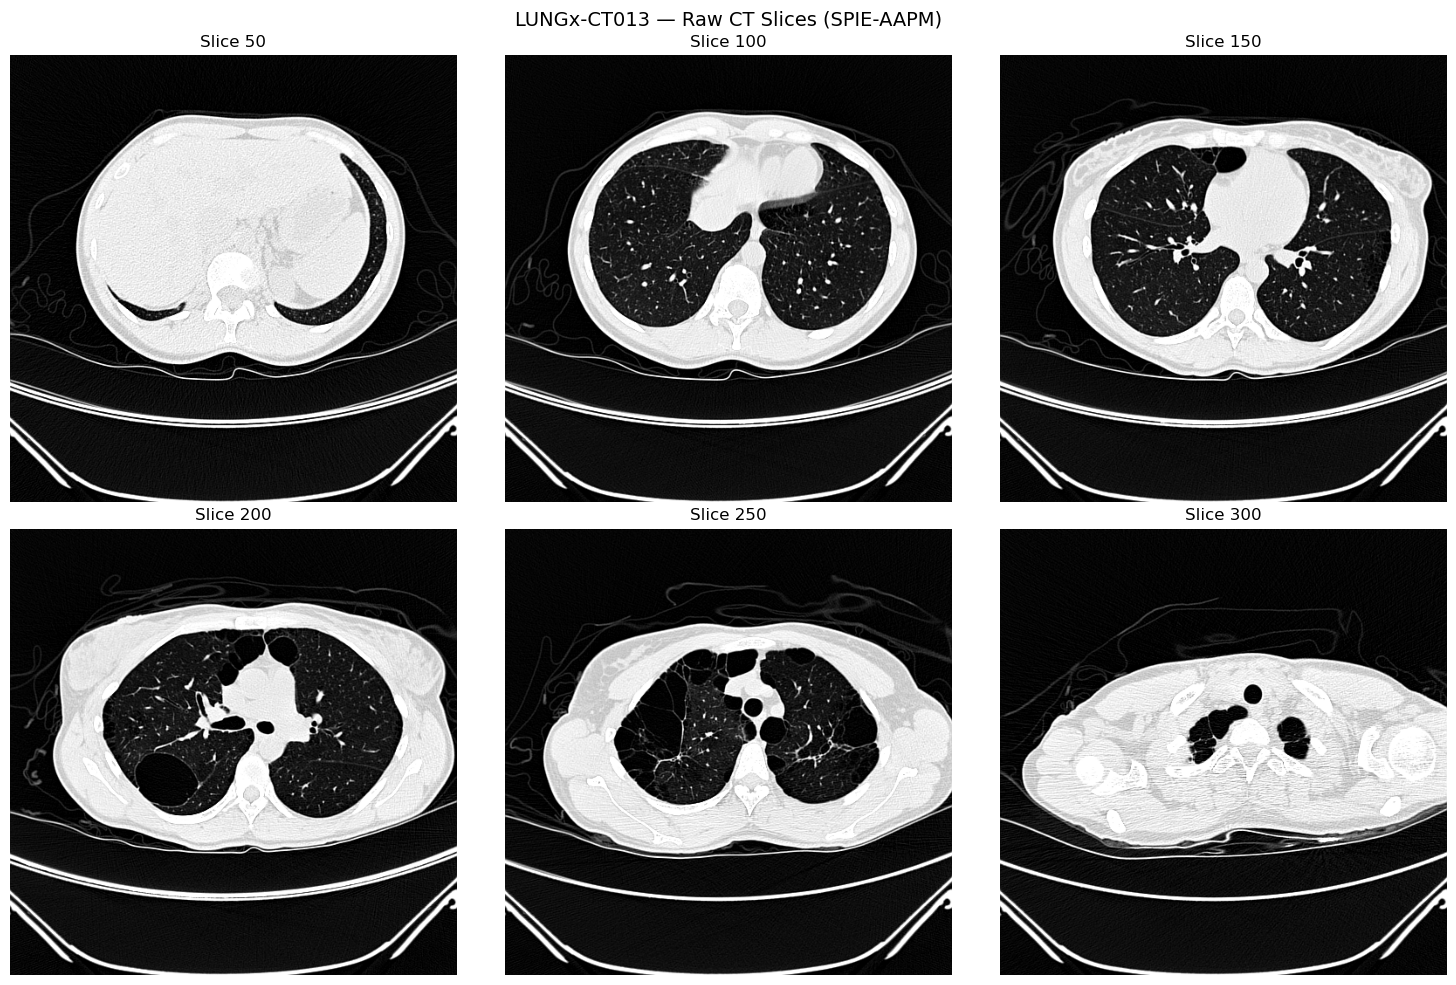

Saved to outputs/01_raw_slices.png


In [20]:
#Converting to Hounsfield Units
'''
What is Hounsfield Units (HU)?
CT scanners don't store brightness directly — they store raw numbers. HU is the standard scale that converts those numbers into something meaningful:

Air = -1000 HU
Lung tissue = -500 HU
Water = 0 HU
Bone = +400 to +1000 HU

'''
def to_hounsfield(slices):
    # astype(int32) is critical — uint16 cannot hold negative HU values
    volume = np.stack([s.pixel_array.astype(np.int32) for s in slices])
    slope = float(slices[0].RescaleSlope)
    intercept = float(slices[0].RescaleIntercept)
    return volume * slope + intercept

hu_volume = to_hounsfield(slices)

print(f"HU range: {hu_volume.min():.0f} to {hu_volume.max():.0f}")
print(f"Volume shape: {hu_volume.shape}  →  (slices, height, width)")

    
def apply_lung_window(volume):
    # Lung window: shows lung tissue clearly
    # Air = -1000 HU, Lung tissue = -500 HU, Soft tissue = 0 to 80 HU
    low, high = -1350, 150
    return np.clip(volume, low, high)

windowed = apply_lung_window(hu_volume)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
indices = [50, 100, 150, 200, 250, 300]

for ax, idx in zip(axes.flatten(), indices):
    ax.imshow(windowed[idx], cmap='gray')
    ax.set_title(f'Slice {idx}')
    ax.axis('off')

plt.suptitle('LUNGx-CT013 — Raw CT Slices (SPIE-AAPM)', fontsize=14)
plt.tight_layout()
plt.savefig("C:/Users/keert/Downloads/lung-ct-segmentation/outputs/01_raw_slices.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/01_raw_slices.png")

    

Lung regions found in slice 150:
  Region 0: area = 26675 pixels
  Region 1: area = 21133 pixels


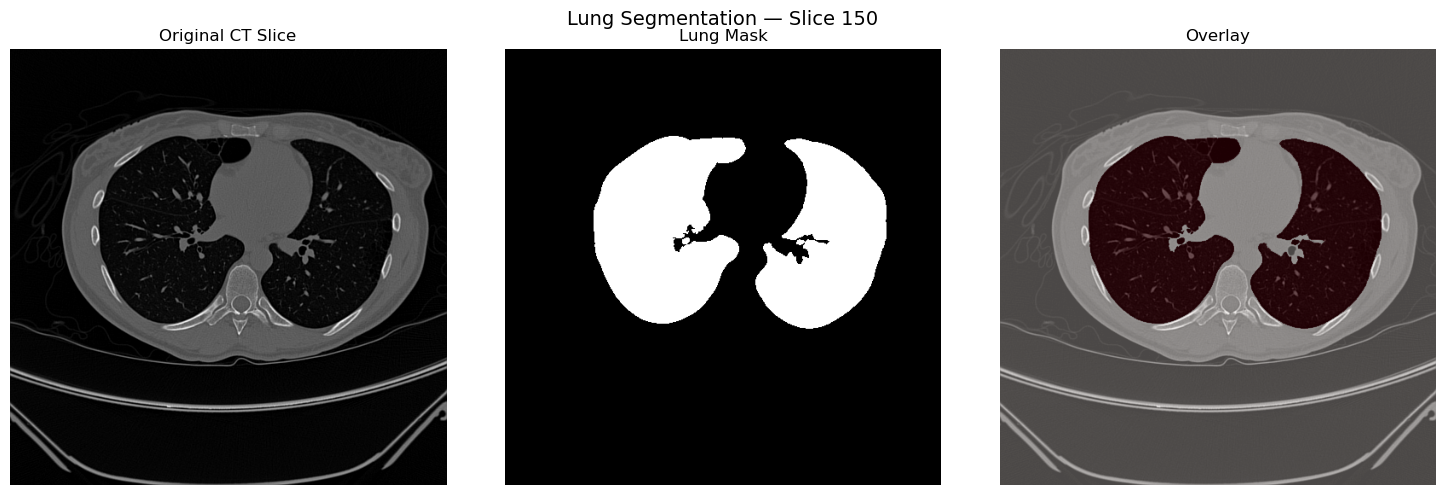

Saved to outputs/02_segmentation.png


In [21]:
# Segmentation

def segment_lungs(hu_volume, slice_idx):

    img = hu_volume[slice_idx]

    # Step 1: Isolate the body — everything above -700 HU is inside the patient
    body_mask = img > -700

    # Step 2: Fill the body into one solid shape
    # This closes the lung holes so we have a complete body outline
    body_filled = ndimage.binary_fill_holes(body_mask)

    # Step 3: Find dark regions INSIDE the body only = lungs
    # Logical AND: must be inside body AND dark enough to be lung air
    lungs_inside = body_filled & (img < -400)

    # Step 4: Remove small noisy blobs — lungs are large, noise is small
    lungs_clean = morphology.remove_small_objects(lungs_inside, min_size=2000)

    # Step 5: Fill small holes inside each lung region
    lungs_final = ndimage.binary_fill_holes(lungs_clean)

    # Step 6: Label and measure each region
    labels = measure.label(lungs_final)
    regions = measure.regionprops(labels)
    regions.sort(key=lambda x: x.area, reverse=True)

    print(f"Lung regions found in slice {slice_idx}:")
    for i, r in enumerate(regions[:4]):
        print(f"  Region {i}: area = {r.area:.0f} pixels")

    return img, lungs_final

slice_idx = 150
original, mask = segment_lungs(hu_volume, slice_idx)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(original, cmap='gray')
axes[0].set_title('Original CT Slice')
axes[0].axis('off')

axes[1].imshow(mask, cmap='gray')
axes[1].set_title('Lung Mask')
axes[1].axis('off')

axes[2].imshow(original, cmap='gray')
axes[2].imshow(mask, cmap='Reds', alpha=0.3)
axes[2].set_title('Overlay')
axes[2].axis('off')

plt.suptitle(f'Lung Segmentation — Slice {slice_idx}', fontsize=14)
plt.tight_layout()
plt.savefig("C:/Users/keert/Downloads/lung-ct-segmentation/outputs/02_segmentation.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/02_segmentation.png")

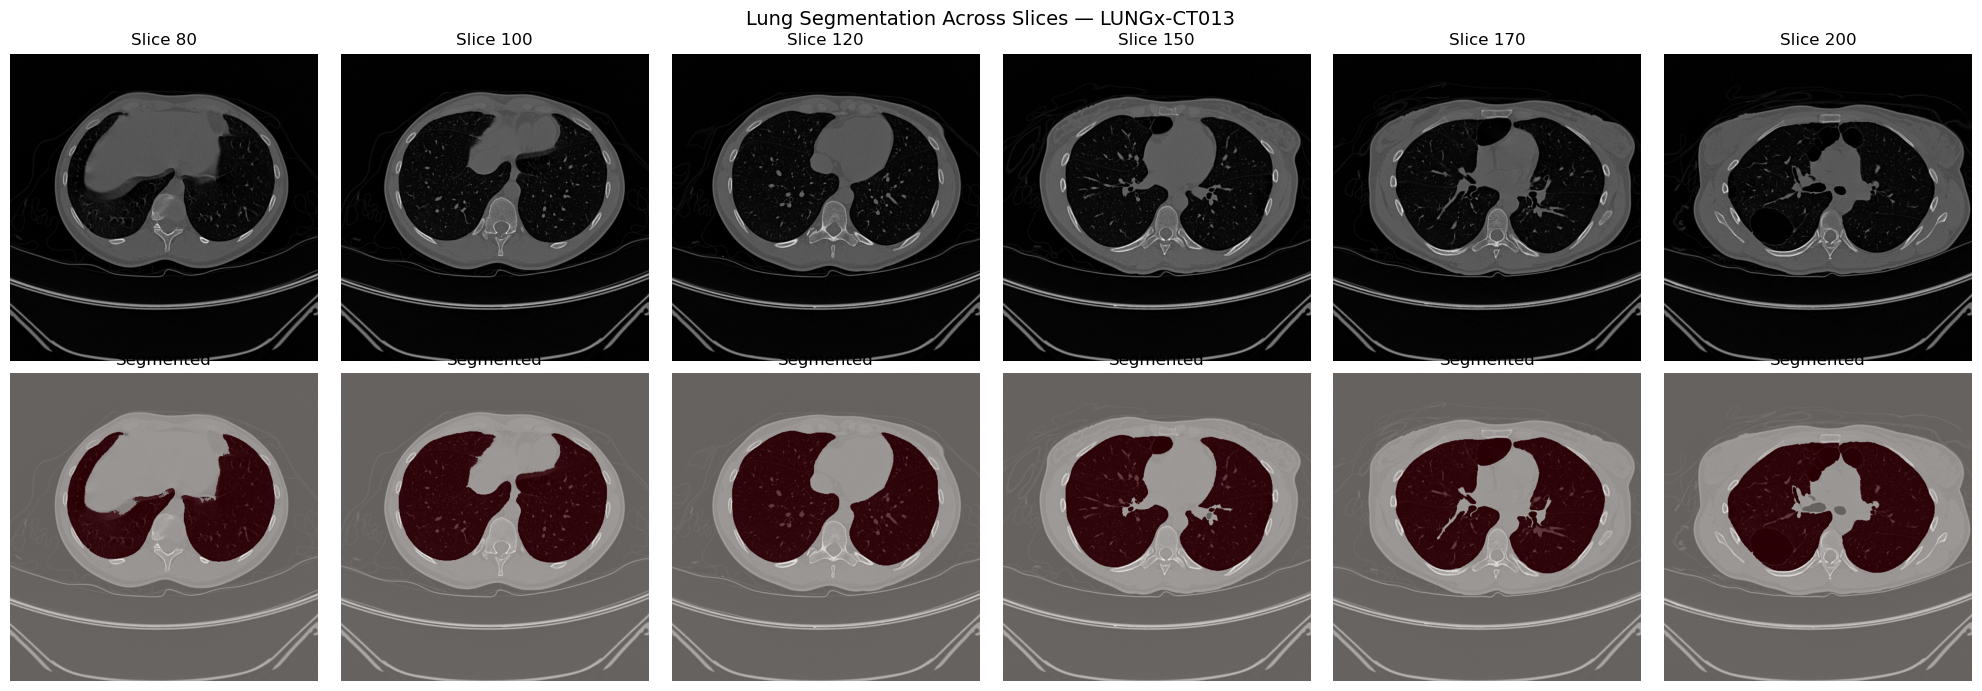

Saved to outputs/03_multi_slice_segmentation.png


In [22]:
# Show segmentation working across 6 different slices
fig, axes = plt.subplots(2, 6, figsize=(20, 7))
slice_indices = [80, 100, 120, 150, 170, 200]

for col, idx in enumerate(slice_indices):
    img = hu_volume[idx]

    # Segmentation
    body_mask = img > -700
    body_filled = ndimage.binary_fill_holes(body_mask)
    lungs_inside = body_filled & (img < -400)
    lungs_clean = morphology.remove_small_objects(lungs_inside, min_size=2000)
    mask = ndimage.binary_fill_holes(lungs_clean)

    # Top row: original
    axes[0][col].imshow(img, cmap='gray')
    axes[0][col].set_title(f'Slice {idx}')
    axes[0][col].axis('off')

    # Bottom row: overlay
    axes[1][col].imshow(img, cmap='gray')
    axes[1][col].imshow(mask, cmap='Reds', alpha=0.4)
    axes[1][col].set_title(f'Segmented')
    axes[1][col].axis('off')

plt.suptitle('Lung Segmentation Across Slices — LUNGx-CT013', fontsize=14)
plt.tight_layout()
plt.savefig("C:/Users/keert/Downloads/lung-ct-segmentation/outputs/03_multi_slice_segmentation.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/03_multi_slice_segmentation.png")

HU values after fix:
  Min:    -1024.0
  Max:    1950.0
  Mean:   -683.2

Pixel counts by HU range:
  Below -700 (air outside):  190710
  -700 to -400 (lung air):   4583
  -400 to 0   (soft tissue): 19347
  Above 0     (bone/vessels):47504
